In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import os
import polars as pl
from towbintools.foundation.file_handling import get_dir_filemap, add_dir_to_experiment_filemap, read_filemap
from joblib import Parallel, delayed
import bottleneck as bn
import seaborn as sns

In [2]:
# change figure size to your liking
plt.rcParams['figure.figsize'] = [12, 10]

# make lines thicker
plt.rcParams['lines.linewidth'] = 3

# make font size bigger
plt.rcParams.update({'font.size': 28})

plt.rcParams['figure.constrained_layout.use'] = True

# ensure fonts are saved as text in svg files
plt.rcParams['svg.fonttype'] = 'none'

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    "pgf.preamble": r"\usepackage{arev}\n\usepackage[T1]{fontenc}"
})

ylim = (0.75, 1.4)

In [3]:
experiment_dir = "/mnt/towbin.data/shared/spsalmon/20260807_134551_682_ZIVA_60x_707_708_col10_reporter"
output_dir = "./plots/20260807_134551_682_ZIVA_60x_707_708_col10_reporter/"
os.makedirs(output_dir, exist_ok=True)
raw_dir = os.path.join(experiment_dir, "raw_stacks")
raw_dir_name = os.path.basename(raw_dir)
analysis_dir = os.path.join(experiment_dir, "analysis_stacks")
report_dir = os.path.join(analysis_dir, "report")

stacks_filemap = get_dir_filemap(raw_dir)
stacks_filemap = stacks_filemap.rename({"ImagePath": raw_dir_name})
mask_dir = os.path.join(analysis_dir, "ch2_seg_cellpose")
stacks_filemap = add_dir_to_experiment_filemap(stacks_filemap, mask_dir, os.path.basename(mask_dir))

classification_dir = None
measurements_directories = ["ch1_cellpose_final_measurements", "ch3_cellpose_final_measurements"]
for measurements_dir in measurements_directories:
    stacks_filemap = add_dir_to_experiment_filemap(stacks_filemap, os.path.join(analysis_dir, measurements_dir), measurements_dir)

stacks_filemap = stacks_filemap.filter(
    pl.all_horizontal(
        [
            (pl.col(measurements_dir).is_not_null()) &
            (pl.col(measurements_dir) != "")
            for measurements_dir in measurements_directories
        ]
    )
)

print(stacks_filemap)

shape: (4_425, 6)
┌──────┬───────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┐
│ Time ┆ Point ┆ raw_stacks         ┆ ch2_seg_cellpose   ┆ ch1_cellpose_final ┆ ch3_cellpose_final │
│ ---  ┆ ---   ┆ ---                ┆ ---                ┆ _measurement…      ┆ _measurement…      │
│ i64  ┆ i64   ┆ str                ┆ str                ┆ ---                ┆ ---                │
│      ┆       ┆                    ┆                    ┆ str                ┆ str                │
╞══════╪═══════╪════════════════════╪════════════════════╪════════════════════╪════════════════════╡
│ 0    ┆ 0     ┆ /mnt/towbin.data/s ┆ /mnt/towbin.data/s ┆ /mnt/towbin.data/s ┆ /mnt/towbin.data/s │
│      ┆       ┆ hared/spsalm…      ┆ hared/spsalm…      ┆ hared/spsalm…      ┆ hared/spsalm…      │
│ 3    ┆ 0     ┆ /mnt/towbin.data/s ┆ /mnt/towbin.data/s ┆ /mnt/towbin.data/s ┆ /mnt/towbin.data/s │
│      ┆       ┆ hared/spsalm…      ┆ hared/spsalm…      ┆ hared/spsalm… 

In [4]:
experiment_filemap_path = os.path.join(experiment_dir, "analysis", "report", "analysis_filemap_annotated.parquet")
experiment_filemap = read_filemap(experiment_filemap_path)
experiment_filemap = experiment_filemap.join(stacks_filemap, on=['Time', 'Point'], how='left')
# remove all the columns with "_at" in their name, as these are not needed for the plotting
experiment_filemap = experiment_filemap.drop([col for col in experiment_filemap.columns if "_at" in col])
# experiment_filemap = experiment_filemap.filter(pl.col("ch1_cellpose_measurements").is_not_null())

experiment_filemap = experiment_filemap.with_columns((pl.col("ExperimentTime") / 3600).alias("ExperimentTimeHours"))

In [5]:
import yaml

def build_conditions(conditions_yaml):
    """
    Process a conditions YAML file structured in a factorized way. Refer to the documentation for the expected format.
    The function will return a list of dictionaries, each representing a condition with its parameters.

    Parameters:
        conditions_yaml (str or dict): Path to the YAML file or a dictionary containing the conditions.
    Returns:
        list: A list of dictionaries, each representing a condition with its parameters.
    Raises:
        ValueError: If the conditions YAML file is not structured correctly.
    """
    if isinstance(conditions_yaml, str):
        with open(conditions_yaml) as file:
            conditions_dict = yaml.safe_load(file)
            file.close()
    elif isinstance(conditions_yaml, dict):
        conditions_dict = conditions_yaml

    conditions = []
    condition_id = 0

    for condition in conditions_dict["conditions"]:
        condition = {
            key: [val] if not isinstance(val, list) else val
            for key, val in condition.items()
        }

        lengths = {len(val) for val in condition.values()}
        if len(lengths) > 2 or (len(lengths) == 2 and 1 not in lengths):
            raise ValueError(
                "All lists in the condition must have the same length or be of length 1."
            )

        max_length = max(lengths)
        for i in range(max_length):
            condition_dict = {
                key: val[0] if len(val) == 1 else val[i]
                for key, val in condition.items()
            }
            condition_dict["condition_id"] = condition_id
            conditions.append(condition_dict)
            condition_id += 1

    return conditions


def _add_conditions_to_filemap(experiment_filemap, conditions):
    """Add conditions to experiment filemap based on point ranges or pad values."""
    if "Pad" in experiment_filemap.columns:
        new_columns = experiment_filemap.select(pl.col("Point"), pl.col("Pad"))
    else:
        new_columns = experiment_filemap.select(pl.col("Point"))
    for condition in conditions:
        # Get condition rows mask
        if "point_range" in condition:
            point_range = condition["point_range"]
            # handle both single range and list of ranges
            if isinstance(point_range[0], list):
                # multiple point ranges - build expressions list
                mask_exprs = [
                    (pl.col("Point") >= pr[0]) & (pl.col("Point") <= pr[1])
                    for pr in point_range
                ]
                # Combine with or operator
                condition_mask = mask_exprs[0]
                for expr in mask_exprs[1:]:
                    condition_mask = condition_mask | expr
            else:
                # single point range
                condition_mask = (pl.col("Point") >= point_range[0]) & (
                    pl.col("Point") <= point_range[1]
                )
            filter_key = "point_range"
        elif "pad" in condition:
            pad = condition["pad"]
            condition_mask = pl.col("Pad") == pad
            filter_key = "pad"
        else:
            print(
                "Condition does not contain 'point_range' or 'pad' key, impossible to add condition to filemap, skipping."
            )
            continue

        # Extract the condition attributes to add (excluding the filter key)
        conditions_to_add = {k: v for k, v in condition.items() if k != filter_key}

        column_ops = []
        for key, val in conditions_to_add.items():
            # For new columns, add with null values first if needed
            if key not in new_columns.columns:
                new_columns = new_columns.with_columns(pl.lit(None).alias(key))

            # Build the column operation but don't apply it yet
            column_ops.append(
                pl.when(condition_mask)
                .then(pl.lit(val))
                .otherwise(pl.col(key))
                .alias(key)
            )

        # Add the new columns to the DataFrame
        if column_ops:
            new_columns = new_columns.with_columns(column_ops)

    if "Pad" in new_columns.columns:
        new_columns = new_columns.drop(["Point", "Pad"])
    else:
        new_columns = new_columns.drop(["Point"])

    # Apply the new columns to the experiment filemap
    if not new_columns.is_empty():
        experiment_filemap = experiment_filemap.with_columns(new_columns)

    return experiment_filemap

In [6]:
condition_id_to_color = {
    0: sns.color_palette("colorblind")[0],
    1: sns.color_palette("colorblind")[1],
}

new_descriptions = {
    0: "control",
    1: "epidermal growth inhibition",
}

In [7]:
condition_file = os.path.join(experiment_dir, "doc", "conditions.yaml")
conditions = build_conditions(condition_file)
# switch condition 0 and 1 to match the new descriptions
for condition in conditions:
    if condition["condition_id"] == 0:
        condition["condition_id"] = 1
    elif condition["condition_id"] == 1:
        condition["condition_id"] = 0
experiment_filemap = _add_conditions_to_filemap(experiment_filemap, conditions)
experiment_filemap

Time,Point,raw,ExperimentTime,analysis/ch1_seg,ch1_seg_area,placeholder_qc,HatchTime,M1,M2,M3,M4,M1Entry,M2Entry,M3Entry,M4Entry,Ignore,Arrest,raw_stacks,ch2_seg_cellpose,ch1_cellpose_final_measurements,ch3_cellpose_final_measurements,ExperimentTimeHours,auxin_concentration,strain,description,condition_id
i64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,str,str,str,str,f64,i32,str,str,i32
0,0,"""/mnt/towbin.data/shared/spsalm…",0.0,"""/mnt/towbin.data/shared/spsalm…",1352.275155,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,"""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…",0.0,1000,"""wBT707""","""col-10:TIR, raga-1:AID, 1mM IA…",1
1,0,"""/mnt/towbin.data/shared/spsalm…",1202.0,"""/mnt/towbin.data/shared/spsalm…",1382.09405,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,null,null,null,null,0.333889,1000,"""wBT707""","""col-10:TIR, raga-1:AID, 1mM IA…",1
2,0,"""/mnt/towbin.data/shared/spsalm…",2402.0,"""/mnt/towbin.data/shared/spsalm…",1369.41515,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,null,null,null,null,0.667222,1000,"""wBT707""","""col-10:TIR, raga-1:AID, 1mM IA…",1
3,0,"""/mnt/towbin.data/shared/spsalm…",3606.0,"""/mnt/towbin.data/shared/spsalm…",1322.221466,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,"""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…",1.001667,1000,"""wBT707""","""col-10:TIR, raga-1:AID, 1mM IA…",1
4,0,"""/mnt/towbin.data/shared/spsalm…",4802.0,"""/mnt/towbin.data/shared/spsalm…",1312.970564,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,null,null,null,null,1.333889,1000,"""wBT707""","""col-10:TIR, raga-1:AID, 1mM IA…",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
198,123,"""/mnt/towbin.data/shared/spsalm…",237600.0,"""/mnt/towbin.data/shared/spsalm…",NaN,"""worm""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,true,false,null,null,null,null,66.0,1000,"""wBT708""","""col-10:TIR, 1mM IAA""",0
199,123,"""/mnt/towbin.data/shared/spsalm…",238272.0,"""/mnt/towbin.data/shared/spsalm…",NaN,"""worm""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,true,false,null,null,null,null,66.186667,1000,"""wBT708""","""col-10:TIR, 1mM IAA""",0
200,123,"""/mnt/towbin.data/shared/spsalm…",239472.0,"""/mnt/towbin.data/shared/spsalm…",NaN,"""worm""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,true,false,null,null,null,null,66.52,1000,"""wBT708""","""col-10:TIR, 1mM IAA""",0


In [8]:
def get_nuclear_stats_per_type(experiment_filemap, channel="ch1", types_to_ignore=['background']):
    rows = []
    def process_row(row, channel):
        measurements_path = row[f"{channel}_cellpose_final_measurements"]
        if measurements_path is None or not os.path.exists(measurements_path):
            return row
        try:
            measurements_df = pl.read_csv(measurements_path)
        except Exception as e:
            return row
    
        # for each unique nucleus type, compute the mean and std of the measurements
        for nucleus_type in measurements_df["Type"].unique():
            if nucleus_type in types_to_ignore:
                continue
            nucleus_type_df = measurements_df.filter(pl.col("Type") == nucleus_type)
            for col in nucleus_type_df.columns:
                if col not in ["Type", "Label", "Z"]:
                    mean_col_name = f"{col}_mean_{nucleus_type}"
                    std_col_name = f"{col}_std_{nucleus_type}"
                    row[mean_col_name] = bn.nanmean(nucleus_type_df[col].to_numpy())
                    row[std_col_name] = bn.nanstd(nucleus_type_df[col].to_numpy())
            row[f"{nucleus_type}_nuclei_count"] = nucleus_type_df.shape[0]
        return row
    
    rows = Parallel(n_jobs=-1)(
        delayed(process_row)(row, channel) 
        for row in tqdm(experiment_filemap.iter_rows(named=True), total=experiment_filemap.height)
    )
    return pl.DataFrame(rows, infer_schema_length=10000)

experiment_filemap = get_nuclear_stats_per_type(experiment_filemap, channel="ch1")

100%|██████████| 25172/25172 [00:10<00:00, 2376.41it/s]


In [9]:
experiment_filemap

Time,Point,raw,ExperimentTime,analysis/ch1_seg,ch1_seg_area,placeholder_qc,HatchTime,M1,M2,M3,M4,M1Entry,M2Entry,M3Entry,M4Entry,Ignore,Arrest,raw_stacks,ch2_seg_cellpose,ch1_cellpose_final_measurements,ch3_cellpose_final_measurements,ExperimentTimeHours,auxin_concentration,strain,description,condition_id,Size_mean_intestine,Size_std_intestine,CentroidX_mean_intestine,CentroidX_std_intestine,CentroidY_mean_intestine,CentroidY_std_intestine,MeanIntensityNucleus_mean_intestine,MeanIntensityNucleus_std_intestine,MedianIntensityNucleus_mean_intestine,MedianIntensityNucleus_std_intestine,…,Size_std_other,CentroidX_mean_other,CentroidX_std_other,CentroidY_mean_other,CentroidY_std_other,MeanIntensityNucleus_mean_other,MeanIntensityNucleus_std_other,MedianIntensityNucleus_mean_other,MedianIntensityNucleus_std_other,MeanIntensityCytoplasm_mean_other,MeanIntensityCytoplasm_std_other,MedianIntensityCytoplasm_mean_other,MedianIntensityCytoplasm_std_other,NucleusCytoplasmRatioMean_mean_other,NucleusCytoplasmRatioMean_std_other,NucleusCytoplasmRatioMedian_mean_other,NucleusCytoplasmRatioMedian_std_other,other_nuclei_count,Size_mean_epidermis,Size_std_epidermis,CentroidX_mean_epidermis,CentroidX_std_epidermis,CentroidY_mean_epidermis,CentroidY_std_epidermis,MeanIntensityNucleus_mean_epidermis,MeanIntensityNucleus_std_epidermis,MedianIntensityNucleus_mean_epidermis,MedianIntensityNucleus_std_epidermis,MeanIntensityCytoplasm_mean_epidermis,MeanIntensityCytoplasm_std_epidermis,MedianIntensityCytoplasm_mean_epidermis,MedianIntensityCytoplasm_std_epidermis,NucleusCytoplasmRatioMean_mean_epidermis,NucleusCytoplasmRatioMean_std_epidermis,NucleusCytoplasmRatioMedian_mean_epidermis,NucleusCytoplasmRatioMedian_std_epidermis,epidermis_nuclei_count
i64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,str,str,str,str,f64,i64,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
0,0,"""/mnt/towbin.data/shared/spsalm…",0.0,"""/mnt/towbin.data/shared/spsalm…",1352.275155,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,"""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…",0.0,1000,"""wBT707""","""col-10:TIR, raga-1:AID, 1mM IA…",1,106.0,42.0,404.135346,18.317779,380.38788,18.497255,208.329814,41.951436,206.0,41.0,…,20.530838,380.853005,46.477947,351.690272,46.715591,122.922015,59.16355,122.178571,60.735847,148.280391,53.081668,142.571429,49.342049,0.8235,0.248084,0.842451,0.252776,14,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1,0,"""/mnt/towbin.data/shared/spsalm…",1202.0,"""/mnt/towbin.data/shared/spsalm…",1382.09405,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,null,null,null,null,0.333889,1000,"""wBT707""","""col-10:TIR, raga-1:AID, 1mM IA…",1,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2,0,"""/mnt/towbin.data/shared/spsalm…",2402.0,"""/mnt/towbin.data/shared/spsalm…",1369.41515,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,null,null,null,null,0.667222,1000,"""wBT707""","""col-10:TIR, raga-1:AID, 1mM IA…",1,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3,0,"""/mnt/towbin.data/shared/spsalm…",3606.0,"""/mnt/towbin.data/shared/spsalm…",1322.221466,"""worm""",7.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,false,false,"""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shared/spsalm…","""/mnt/towbin.data/shar

# Binned plots

In [10]:
# molts = ['M1', 'M2', 'M3', 'M4']
# column_to_plot = "NucleusCytoplasmRatioMedian_mean_epidermis"


# color_palette = plt.get_cmap("tab10")


# for molt in molts:
    
#     modified_point_filemaps = []
#     for point_filemap in experiment_filemap.partition_by("Point", maintain_order=True):
#         molt_time = point_filemap[molt][0]

#         if molt_time is None:
#             modified_point_filemaps.append(point_filemap.with_columns(
#                 pl.lit(np.nan).alias(f"ExperimentTimeHoursRelativeTo{molt}")
#             ))

#         else:
#             molt_time = float(molt_time)
#             point = point_filemap["Point"][0]

#             molt_experiment_time = (
#                 point_filemap
#                 .filter(pl.col("Time") == molt_time)
#                 .select("ExperimentTimeHours")
#                 .item()
#             )
#             modified_point_filemaps.append(
#                 point_filemap.with_columns(
#                     (pl.col("ExperimentTimeHours") - molt_experiment_time).alias(f"ExperimentTimeHoursRelativeTo{molt}")
#                 )
#             )

#     experiment_filemap = pl.concat(modified_point_filemaps).sort(["Point", "Time"])

#     filemap_for_plotting = experiment_filemap.filter((pl.col(f"ExperimentTimeHoursRelativeTo{molt}") >= -8) & (pl.col(f"ExperimentTimeHoursRelativeTo{molt}") <= 8))

#     filemap_for_plotting = filemap_for_plotting.with_columns(
#         (pl.col(f"ExperimentTimeHoursRelativeTo{molt}") // 1).alias(f"ExperimentTimeHoursRelativeTo{molt}Bin")
#     )
#     # remove all the rows with null values in the column to plot
#     filemap_for_plotting = filemap_for_plotting.filter(pl.col(f"ExperimentTimeHoursRelativeTo{molt}Bin").is_not_null())
#     filemap_for_plotting = filemap_for_plotting.filter(pl.col(column_to_plot).is_not_null())
#     conditions_filemaps = filemap_for_plotting.partition_by("condition_id", maintain_order=True)

#     for i, condition_filemap in enumerate(conditions_filemaps):
#         condition_id = condition_filemap["condition_id"][0]
#         description = condition_filemap["description"][0]
#         n_points = condition_filemap.select(pl.col("Point").n_unique()).item()
#         mean_values = (
#             condition_filemap
#             .group_by(f"ExperimentTimeHoursRelativeTo{molt}Bin")
#             .agg(pl.mean(column_to_plot).alias(column_to_plot))
#             .sort(f"ExperimentTimeHoursRelativeTo{molt}Bin")
#         )
#         std_values = (
#             condition_filemap        
#             .group_by(f"ExperimentTimeHoursRelativeTo{molt}Bin")
#             .agg(pl.std(column_to_plot).alias(column_to_plot))
#             .sort(f"ExperimentTimeHoursRelativeTo{molt}Bin")
#         )

#         ste_values = std_values.with_columns(
#             (pl.col(column_to_plot) / np.sqrt(n_points)).alias("ste")
#         )
#         plt.plot(mean_values[f"ExperimentTimeHoursRelativeTo{molt}Bin"], mean_values[column_to_plot], color = condition_id_to_color[condition_id], label=f"{description}: n={n_points}")
#         plt.fill_between(
#             mean_values[f"ExperimentTimeHoursRelativeTo{molt}Bin"],
#             mean_values[column_to_plot] - 1.96 * ste_values["ste"],
#             mean_values[column_to_plot] + 1.96 * ste_values["ste"],
#             alpha=0.3,
#             color = condition_id_to_color[condition_id]
#         )

#     plt.xlabel(f'time (hours relative to {molt})')
#     plt.ylabel('average nucleus/cytoplasm ratio')
#     plt.legend()
#     plt.savefig(os.path.join(output_dir, f"{column_to_plot}_relative_to_{molt}.pdf"))
#     plt.show()


# Rescaled plots

In [11]:
def separate_column_by_point(filemap, column):
    points = (
        filemap.select(pl.col("Point").unique(maintain_order=True).sort())
        .to_numpy()
        .flatten()
    )

    filemap_points = filemap.select(pl.col("Point"), pl.col(column))
    point_dataframes = filemap_points.partition_by("Point", maintain_order=True)

    sample = point_dataframes[0].select(pl.col(column)).head(1).item()
    is_string = isinstance(sample, str) or (
        hasattr(sample, "dtype") and np.issubdtype(sample.dtype, np.str_)
    )

    max_height = max(point_df.height for point_df in point_dataframes)
    if is_string:
        result = np.full((len(points), max_height), "error", dtype=object)
    else:
        result = np.full((len(points), max_height), np.nan)

    for i, point_df in enumerate(point_dataframes):
        point_column = point_df.select(pl.col(column)).to_numpy().squeeze()
        result[i, : len(point_column)] = point_column
    return result

def _get_time_ecdysis_and_durations(filemap):
    all_ecdysis_time_step = []
    all_ecdysis_index = []
    all_durations_time_step = []

    all_ecdysis_experiment_time = []
    all_durations_experiment_time = []

    ecdysis_columns = ["HatchTime", "M1", "M2", "M3", "M4"]
    column_list = ["Point", "Time", "ExperimentTime"] + ecdysis_columns
    filemap = filemap.select(pl.col(column_list))

    ecdysis_values = (
        filemap.group_by("Point", maintain_order=True)
        .agg(pl.col(ecdysis_columns).first())
        .drop("Point")
        .cast(pl.Float64)
    )

    time = separate_column_by_point(filemap, "Time").astype(float)
    experiment_time = separate_column_by_point(filemap, "ExperimentTime").astype(float)

    for i in range(len(ecdysis_values)):
        ecdysis = ecdysis_values[i].to_numpy().squeeze()
        time_of_point = time[i]
        experiment_time_of_point = experiment_time[i]

        ecdysis_index = [
            float(np.where(time_of_point == ecdysis)[0][0])
            if ecdysis in time_of_point
            else np.nan
            for ecdysis in ecdysis
        ]
        ecdysis_experiment_time = [
            experiment_time_of_point[int(index)] if not np.isnan(index) else np.nan
            for index in ecdysis_index
        ]
        all_ecdysis_time_step.append(ecdysis)
        all_ecdysis_index.append(ecdysis_index)
        all_ecdysis_experiment_time.append(ecdysis_experiment_time)

    return (
        time,
        experiment_time,
        np.array(all_ecdysis_index),
        np.array(all_ecdysis_time_step),
        np.array(all_ecdysis_experiment_time),
    )

import os
from collections.abc import Mapping, Sequence

import numpy as np
import matplotlib.pyplot as plt
import bottleneck as bn

from towbintools.data_analysis import rescale_series

DEFAULT_STAGE_NAMES = ["L1", "L2", "L3", "L4"]


def _resolve_stage_limits(n_stages, condition_ids, max_stages=4):
    """Normalize n_stages into {condition_id: n_stages_for_that_condition}."""
    if n_stages is None:
        return {cid: max_stages for cid in condition_ids}
    if isinstance(n_stages, Mapping):
        return {cid: int(n_stages.get(cid, max_stages)) for cid in condition_ids}
    if isinstance(n_stages, Sequence) and not isinstance(n_stages, (str, bytes)):
        if len(n_stages) != len(condition_ids):
            raise ValueError(
                f"n_stages has {len(n_stages)} entries but there are "
                f"{len(condition_ids)} conditions {condition_ids}"
            )
        return {cid: int(v) for cid, v in zip(condition_ids, n_stages)}
    return {cid: int(n_stages) for cid in condition_ids}


def rescale_and_plot(
    experiment_filemap,
    column,
    *,
    n_points=25,
    n_stages=4,
    descriptions=None,
    colors=None,
    ylabel=None,
    xlabel="larval stage progression (%)",
    stage_names=None,
    ylim=None,
    xlim=(0, 100),
    ci=1.96,
    alpha=0.3,
    figsize_per_stage=(6, 8),
    sharey=True,
    output_dir=None,
    filename=None,
    show=True,
    verbose=True,
    axes=None,
):
    """
    Plot the stage-rescaled mean (+/- CI) of `column`, one subplot per larval stage.

    Parameters
    ----------
    column : str
        Column of `experiment_filemap` to plot.
    n_stages : int | Sequence[int] | Mapping[condition_id, int]
        How many stages to plot per condition. A sequence is matched positionally
        to the partition order; a mapping is keyed by condition_id (recommended).
    descriptions, colors : Mapping[condition_id, str], optional
        Legend labels / line colors. Falls back to the filemap's `description`
        column and matplotlib's default cycle.
    output_dir, filename : str, optional
        If `output_dir` is given, the figure is saved there. `filename` defaults
        to f"{column}_rescaled.pdf".

    Returns
    -------
    fig, axes
    """
    conditions_filemaps = experiment_filemap.partition_by(
        "condition_id", maintain_order=True
    )
    condition_ids = [cfm["condition_id"][0] for cfm in conditions_filemaps]
    limits = _resolve_stage_limits(n_stages, condition_ids)

    max_stages = max(limits.values())
    stage_names = (stage_names or DEFAULT_STAGE_NAMES)[:max_stages]

    if axes is None:
        fig, axes = plt.subplots(
            1,
            max_stages,
            sharey=sharey,
            figsize=(figsize_per_stage[0] * max_stages, figsize_per_stage[1]),
        )
        axes = np.atleast_1d(axes)
    else:
        axes = np.atleast_1d(axes)
        fig = axes[0].get_figure()

    x = np.linspace(0, 100, n_points)

    for condition_filemap, condition_id in zip(conditions_filemaps, condition_ids):
        series_values = separate_column_by_point(condition_filemap, column)
        (
            time,
            experiment_time,
            ecdysis_index,
            ecdysis,
            ecdysis_experiment_time,
        ) = _get_time_ecdysis_and_durations(condition_filemap)

        keep = ~np.isnan(series_values).all(axis=1)
        if not keep.any():
            if verbose:
                print(f"Condition {condition_id}: no valid series, skipping.")
            continue

        series_values = series_values[keep]
        experiment_time = experiment_time[keep]
        ecdysis_index = ecdysis_index[keep]
        qc = np.full_like(series_values, "worm", dtype=object)

        _, rescaled = rescale_series(
            series_values, experiment_time, ecdysis_index, qc, n_points=n_points
        )  # (n_worms, 4, n_points)

        n_stages_condition = limits[condition_id]
        rescaled = rescaled.reshape(rescaled.shape[0], -1)
        rescaled = rescaled[:, : n_points * n_stages_condition]

        label = (
            descriptions[condition_id]
            if descriptions is not None
            else condition_filemap["description"][0]
        )
        color = colors.get(condition_id) if colors is not None else None

        if verbose:
            print(f"Number of points for condition {label}: {rescaled.shape[0]}")

        mean_series = bn.nanmean(rescaled, axis=0)
        std_series = bn.nanstd(rescaled, axis=0)
        counts = np.sum(~np.isnan(rescaled), axis=0)
        ste_series = np.divide(
            std_series,
            np.sqrt(counts),
            out=np.full_like(std_series, np.nan),
            where=counts > 0,
        )

        for stage in range(n_stages_condition):
            sl = slice(stage * n_points, (stage + 1) * n_points)
            ax = axes[stage]
            mean_stage, ste_stage = mean_series[sl], ste_series[sl]
            (line,) = ax.plot(x, mean_stage, label=label, color=color)
            ax.fill_between(
                x,
                mean_stage - ci * ste_stage,
                mean_stage + ci * ste_stage,
                alpha=alpha,
                color=line.get_color(),
            )

    for stage, ax in enumerate(axes):
        ax.set_title(stage_names[stage])
        ax.set_ylim(ylim)
        ax.set_xlim(xlim)

    axes[0].set_ylabel(ylabel if ylabel is not None else column)

    handles, labels = [], []
    for ax in axes:
        for hi, li in zip(*ax.get_legend_handles_labels()):
            if li not in labels:
                handles.append(hi)
                labels.append(li)
    if handles:
        fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.98, 0.5))

    fig.supxlabel(xlabel)

    if output_dir is not None:
        path = os.path.join(output_dir, filename or f"{column}_rescaled.pdf")
        fig.savefig(path, bbox_inches="tight")

    if show:
        plt.show()

    return fig, axes

Number of points for condition epidermal growth inhibition: 65
Number of points for condition control: 59


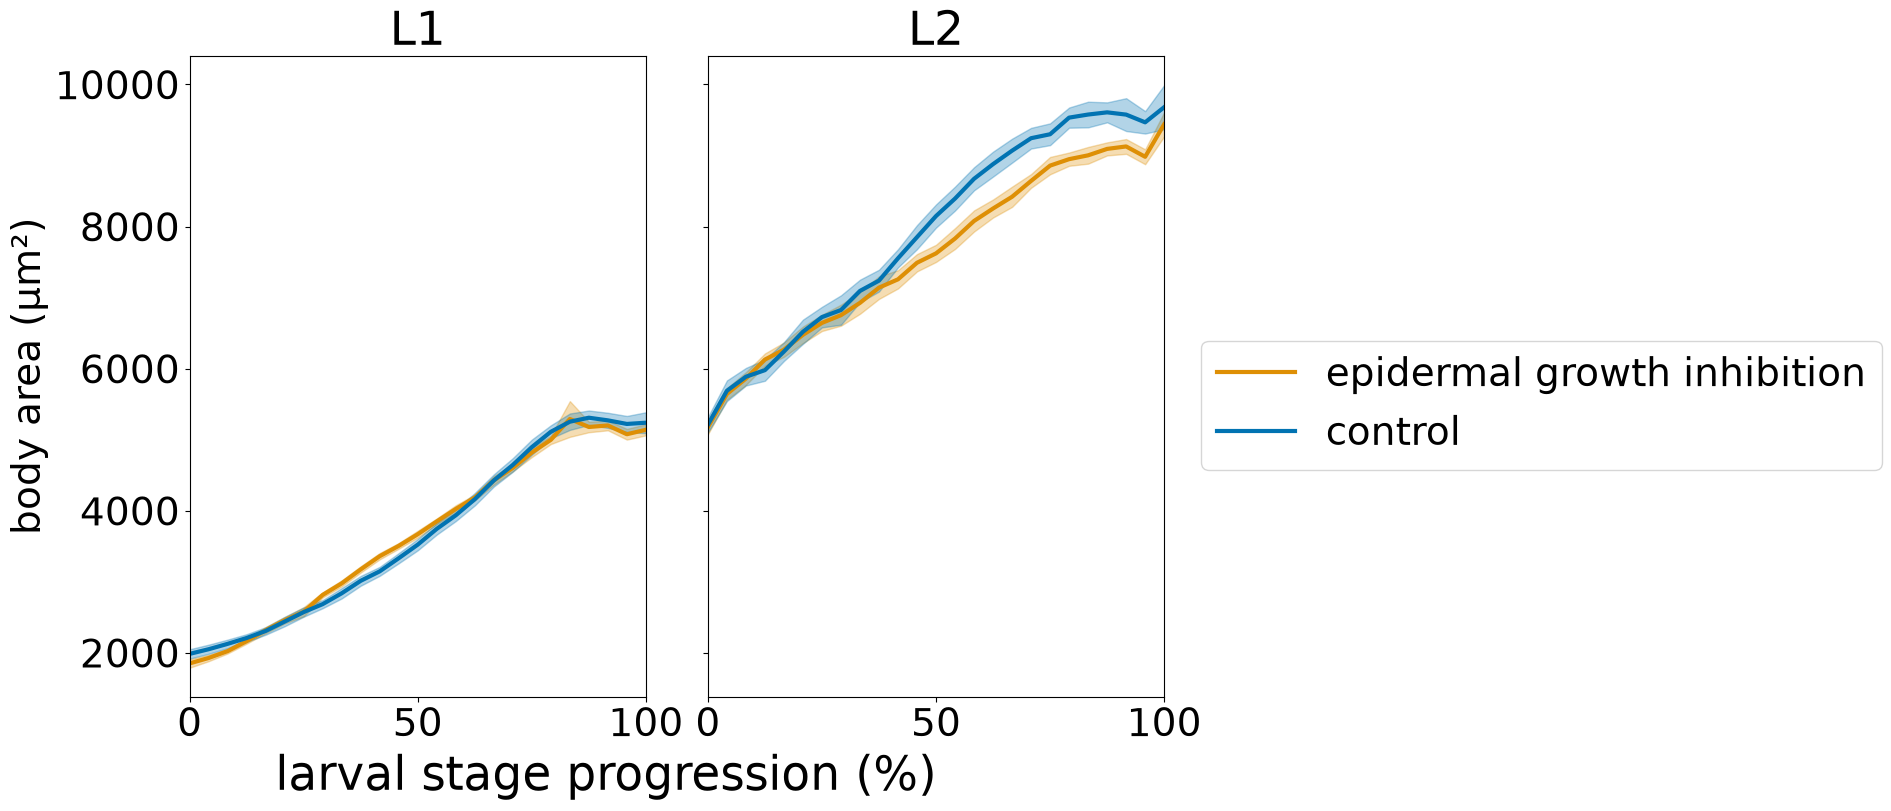

In [12]:
fig, axes = rescale_and_plot(
    experiment_filemap,
    "ch1_seg_area",
    n_points=25,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    colors=condition_id_to_color,
    ylabel="body area (µm²)",
    output_dir=output_dir,
    filename="body_area_rescaled.pdf",
)

Number of points for condition epidermal growth inhibition: 60
Number of points for condition control: 39


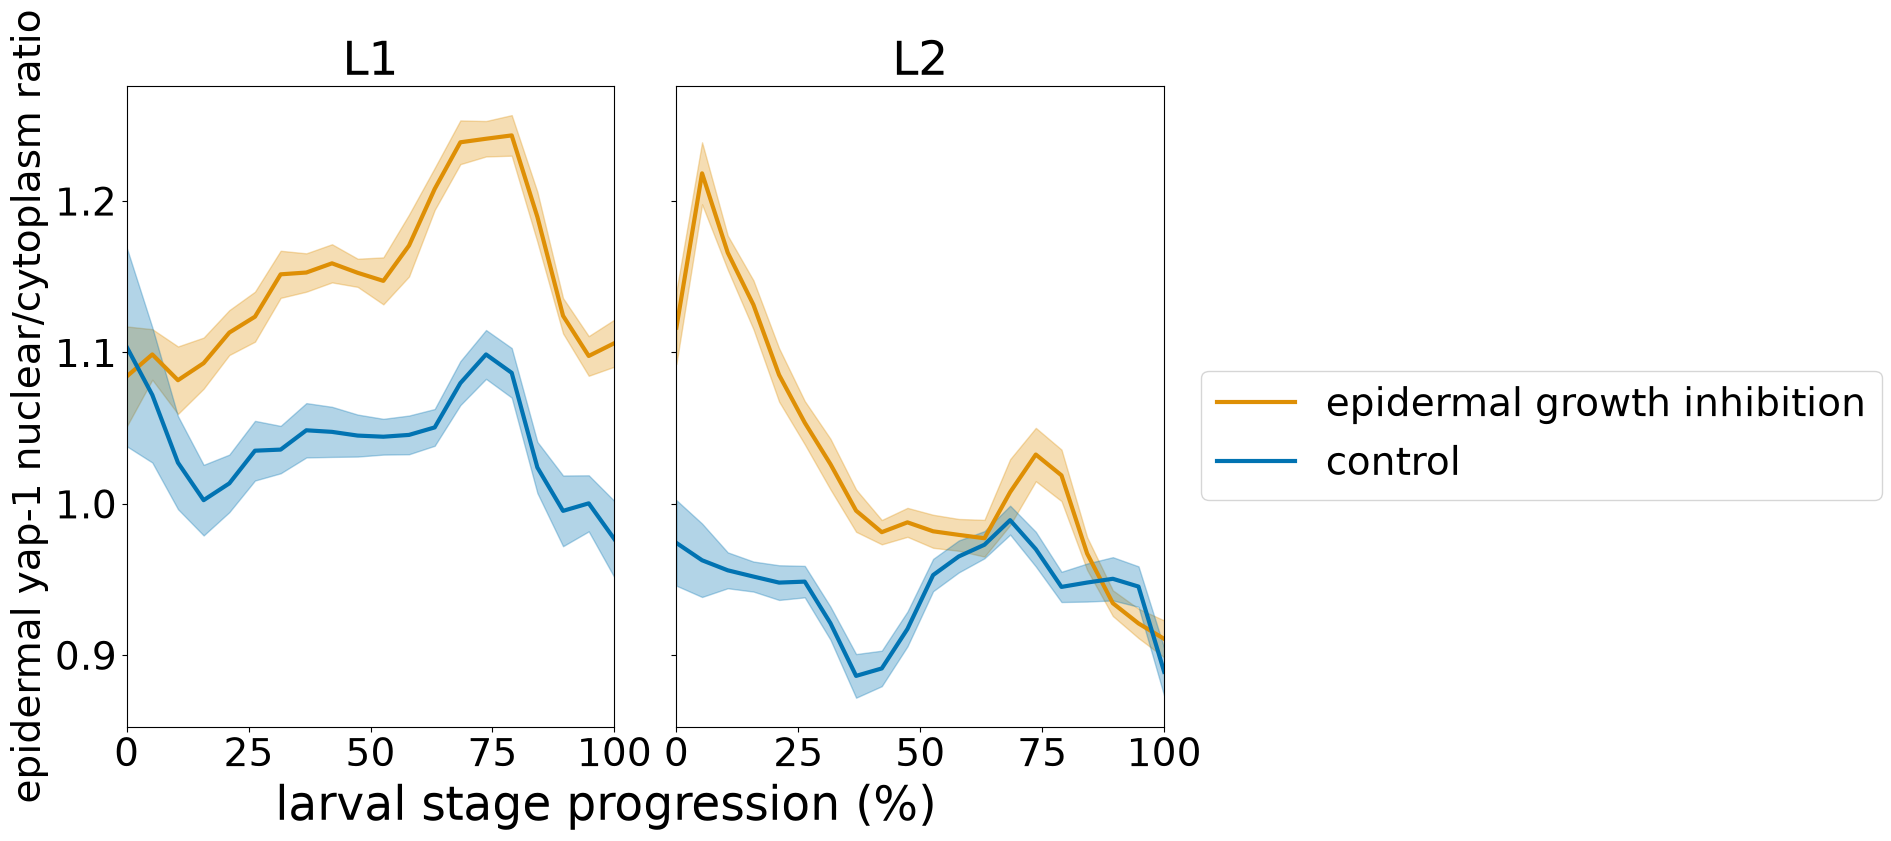

In [13]:
fig, axes = rescale_and_plot(
    experiment_filemap,
    "NucleusCytoplasmRatioMedian_mean_epidermis",
    n_points=20,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    colors=condition_id_to_color,
    ylabel="epidermal yap-1 nuclear/cytoplasm ratio",
    output_dir=output_dir,
    filename="epidermal_nucleus_cytoplasm_ratio_rescaled.pdf",
)


Number of points for condition epidermal growth inhibition: 60
Number of points for condition control: 39


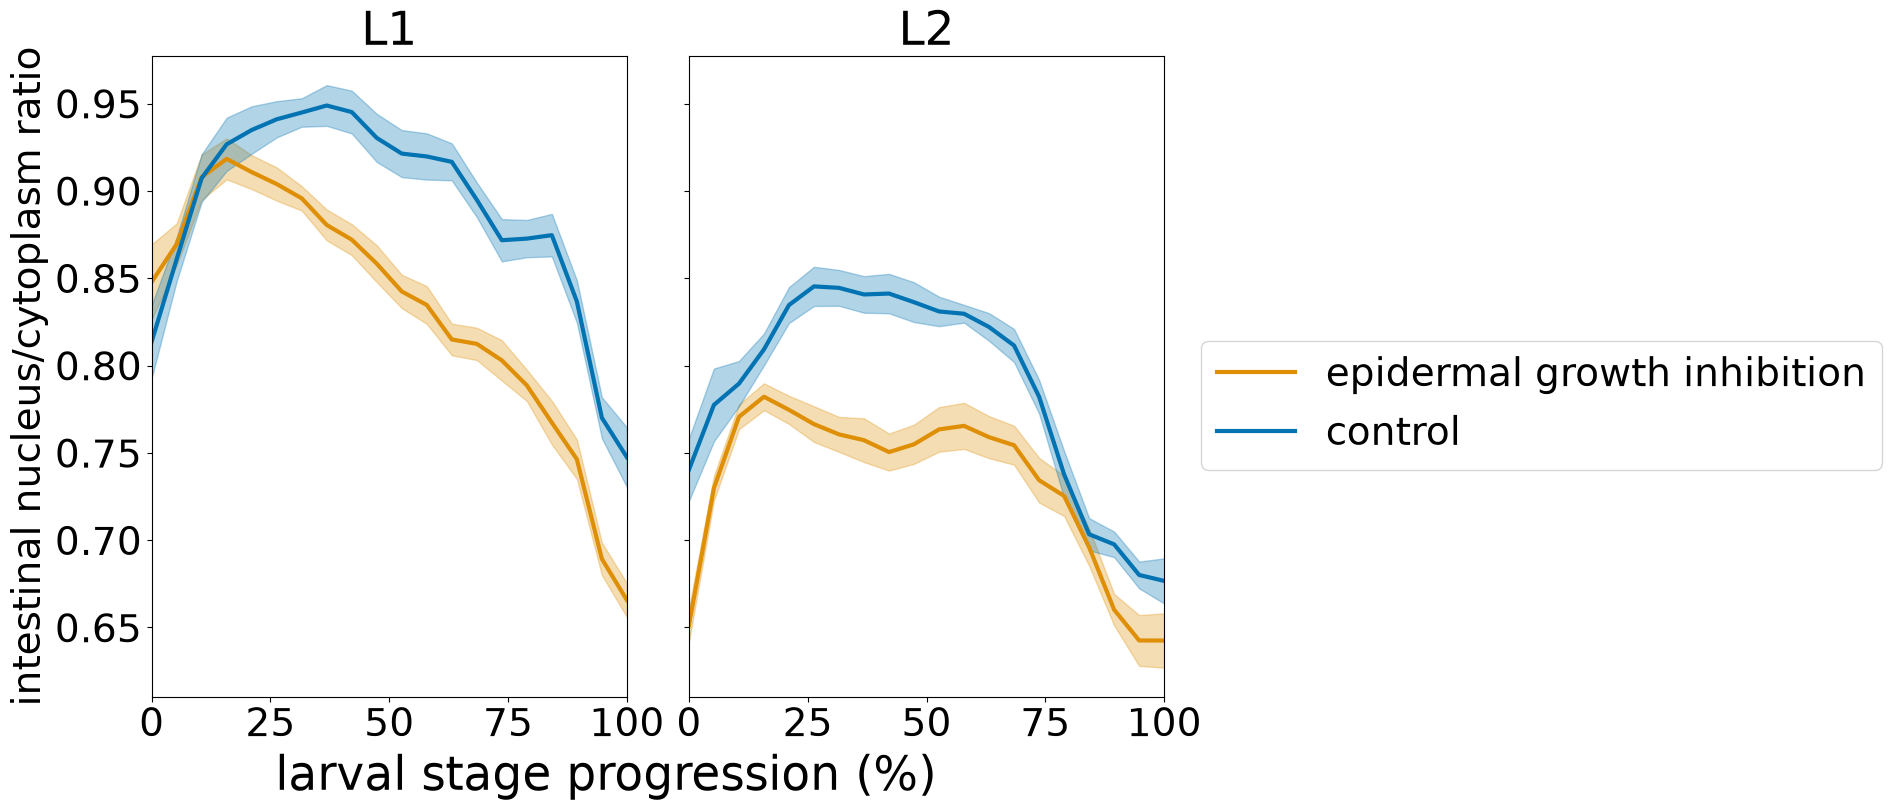

In [14]:
fig, axes = rescale_and_plot(
    experiment_filemap,
    "NucleusCytoplasmRatioMedian_mean_intestine",
    n_points=20,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    colors=condition_id_to_color,
    ylabel="intestinal nucleus/cytoplasm ratio",
    output_dir=output_dir,
    filename="intestinal_nucleus_cytoplasm_ratio_rescaled.pdf",
)


# get col-10 stats

In [15]:
import os
import polars as pl

channel = "ch3"
col = f"{channel}_cellpose_final_measurements"

paths = [p for p in experiment_filemap[col].drop_nulls().to_list() if os.path.exists(p)]

nuclei = (
    pl.scan_csv(paths, include_file_paths=col)
    .select("Size", "MedianIntensityNucleus", col)
    .collect()  # engine="streaming" if it doesn't fit comfortably in RAM
)

# attach whatever metadata you need (Time, Point, Condition, ...)
nuclei = nuclei.join(
    experiment_filemap.select([col, "Time", "Point"]),
    on=col,
    how="left",
)

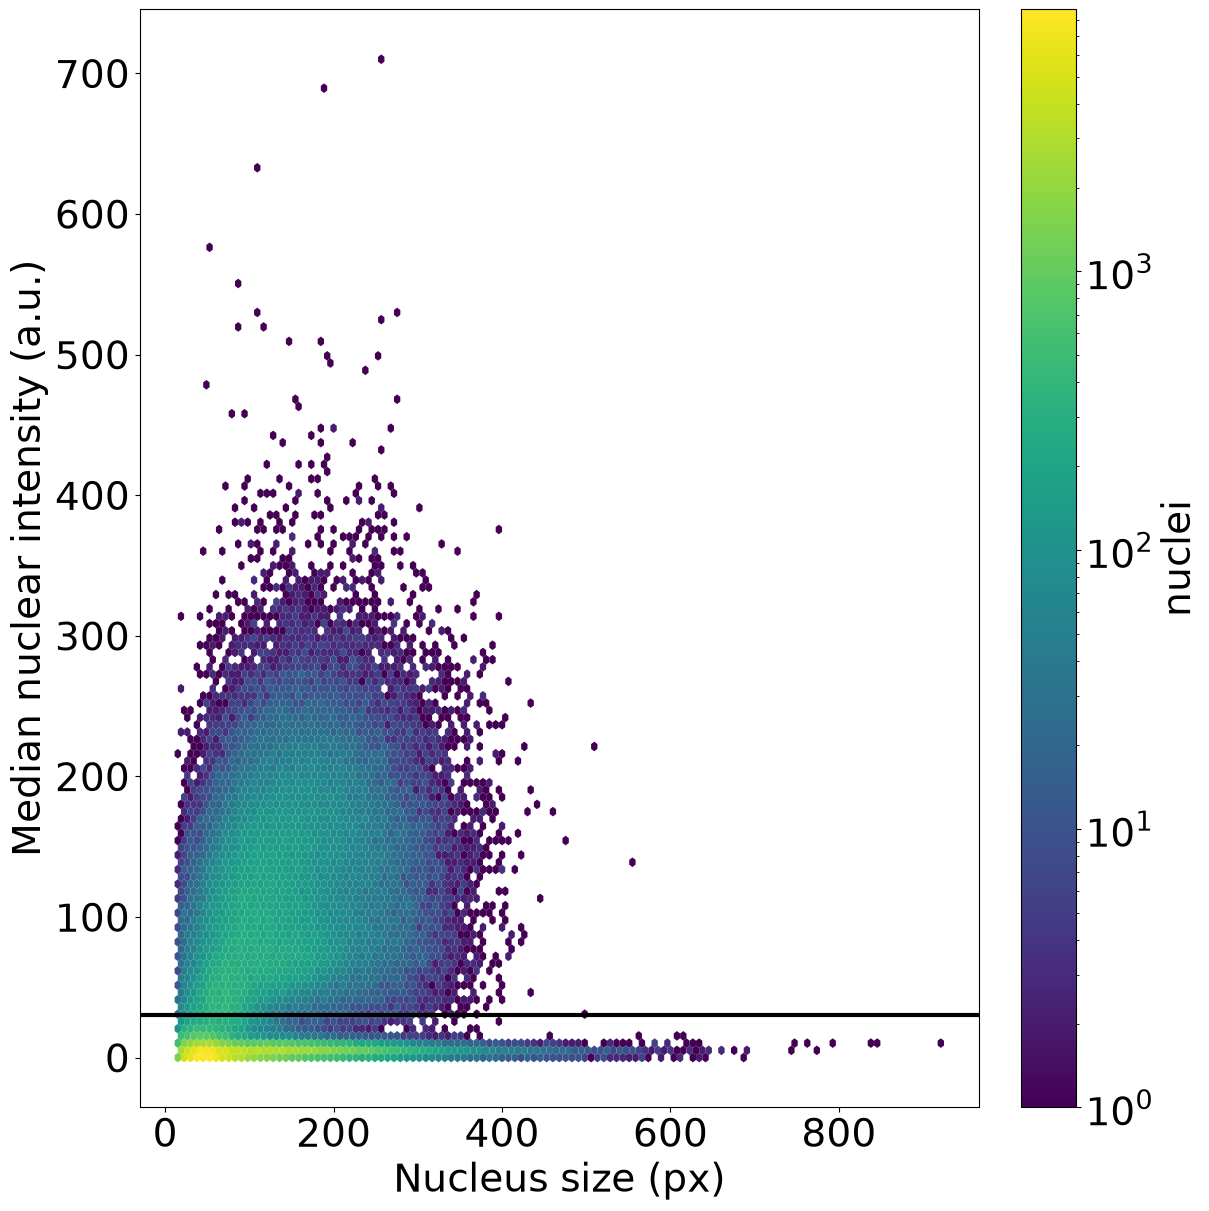

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
nuclei = nuclei.with_columns(
    pl.col("Size", "MedianIntensityNucleus").cast(pl.Float64, strict=False)
)

fig, ax = plt.subplots(figsize=(12, 12))
hb = ax.hexbin(
    nuclei["Size"], nuclei["MedianIntensityNucleus"],
    gridsize=120, bins="log", mincnt=1, linewidths=0,
)
ax.set(xlabel="Nucleus size (px)", ylabel="Median nuclear intensity (a.u.)")
ax.axhline(y=30, color="k", linewidth=3)
fig.colorbar(hb, ax=ax, label="nuclei")

In [17]:
import os
import polars as pl
from joblib import Parallel, delayed
from tqdm.auto import tqdm


def _measurement_stats(idx, path, min_intensity, intensity_col, exclude, prefix):
    """Per-file aggregation. Returns {} for stats if the file is unusable."""
    out = {"_row_idx": idx}
    if path is None or not os.path.exists(path):
        return out
    try:
        df = pl.read_csv(path, infer_schema_length=None)
    except Exception:
        return out
    if intensity_col not in df.columns:
        return out

    value_cols = [c for c in df.columns if c not in exclude]
    # strict=False turns junk into null; fill_nan matches bottleneck's nan-skipping
    df = df.select(
        pl.col(c).cast(pl.Float64, strict=False).fill_nan(None) for c in value_cols
    )

    n_total = df.height
    df = df.filter(pl.col(intensity_col) >= min_intensity)
    n_kept = df.height

    agg = df.select(
        [pl.col(c).mean().alias(f"{prefix}{c}_mean") for c in value_cols]
        + [pl.col(c).std().alias(f"{prefix}{c}_std") for c in value_cols]
        + [pl.col(c).median().alias(f"{prefix}{c}_median") for c in value_cols]
    ).row(0, named=True)  # 1 row of nulls when n_kept == 0

    out.update(agg)
    out[f"{prefix}nuclei_count"] = n_kept
    out[f"{prefix}nuclei_total"] = n_total
    out[f"{prefix}nuclei_frac"] = n_kept / n_total if n_total else None
    return out


def add_measurement_stats(
    experiment_filemap,
    channel="ch3",
    min_nuclear_intensity=30,
    intensity_col="MedianIntensityNucleus",
    exclude=("Type", "Label", "Z"),
    prefix="col10_",
    n_jobs=-1,
):
    path_col = f"{channel}_cellpose_final_measurements"
    fm = experiment_filemap.with_row_index("_row_idx")
    paths = fm[path_col].to_list()

    results = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(_measurement_stats)(
            i, p, min_nuclear_intensity, intensity_col, exclude, prefix
        )
        for i, p in tqdm(enumerate(paths), total=len(paths))
    )

    # normalise keys so files with differing column sets still align
    keys = sorted({k for r in results for k in r} - {"_row_idx"})
    stats = pl.DataFrame(
        [{"_row_idx": r["_row_idx"], **{k: r.get(k) for k in keys}} for r in results],
        infer_schema_length=None,
    ).with_columns(pl.col("_row_idx").cast(pl.UInt32))

    return fm.join(stats, on="_row_idx", how="left").drop("_row_idx")


experiment_filemap = add_measurement_stats(experiment_filemap, channel="ch3")

  0%|          | 0/25172 [00:00<?, ?it/s]

['Time', 'Point', 'raw', 'ExperimentTime', 'analysis/ch1_seg', 'ch1_seg_area', 'placeholder_qc', 'HatchTime', 'M1', 'M2', 'M3', 'M4', 'M1Entry', 'M2Entry', 'M3Entry', 'M4Entry', 'Ignore', 'Arrest', 'raw_stacks', 'ch2_seg_cellpose', 'ch1_cellpose_final_measurements', 'ch3_cellpose_final_measurements', 'ExperimentTimeHours', 'auxin_concentration', 'strain', 'description', 'condition_id', 'Size_mean_intestine', 'Size_std_intestine', 'CentroidX_mean_intestine', 'CentroidX_std_intestine', 'CentroidY_mean_intestine', 'CentroidY_std_intestine', 'MeanIntensityNucleus_mean_intestine', 'MeanIntensityNucleus_std_intestine', 'MedianIntensityNucleus_mean_intestine', 'MedianIntensityNucleus_std_intestine', 'MeanIntensityCytoplasm_mean_intestine', 'MeanIntensityCytoplasm_std_intestine', 'MedianIntensityCytoplasm_mean_intestine', 'MedianIntensityCytoplasm_std_intestine', 'NucleusCytoplasmRatioMean_mean_intestine', 'NucleusCytoplasmRatioMean_std_intestine', 'NucleusCytoplasmRatioMedian_mean_intestine',

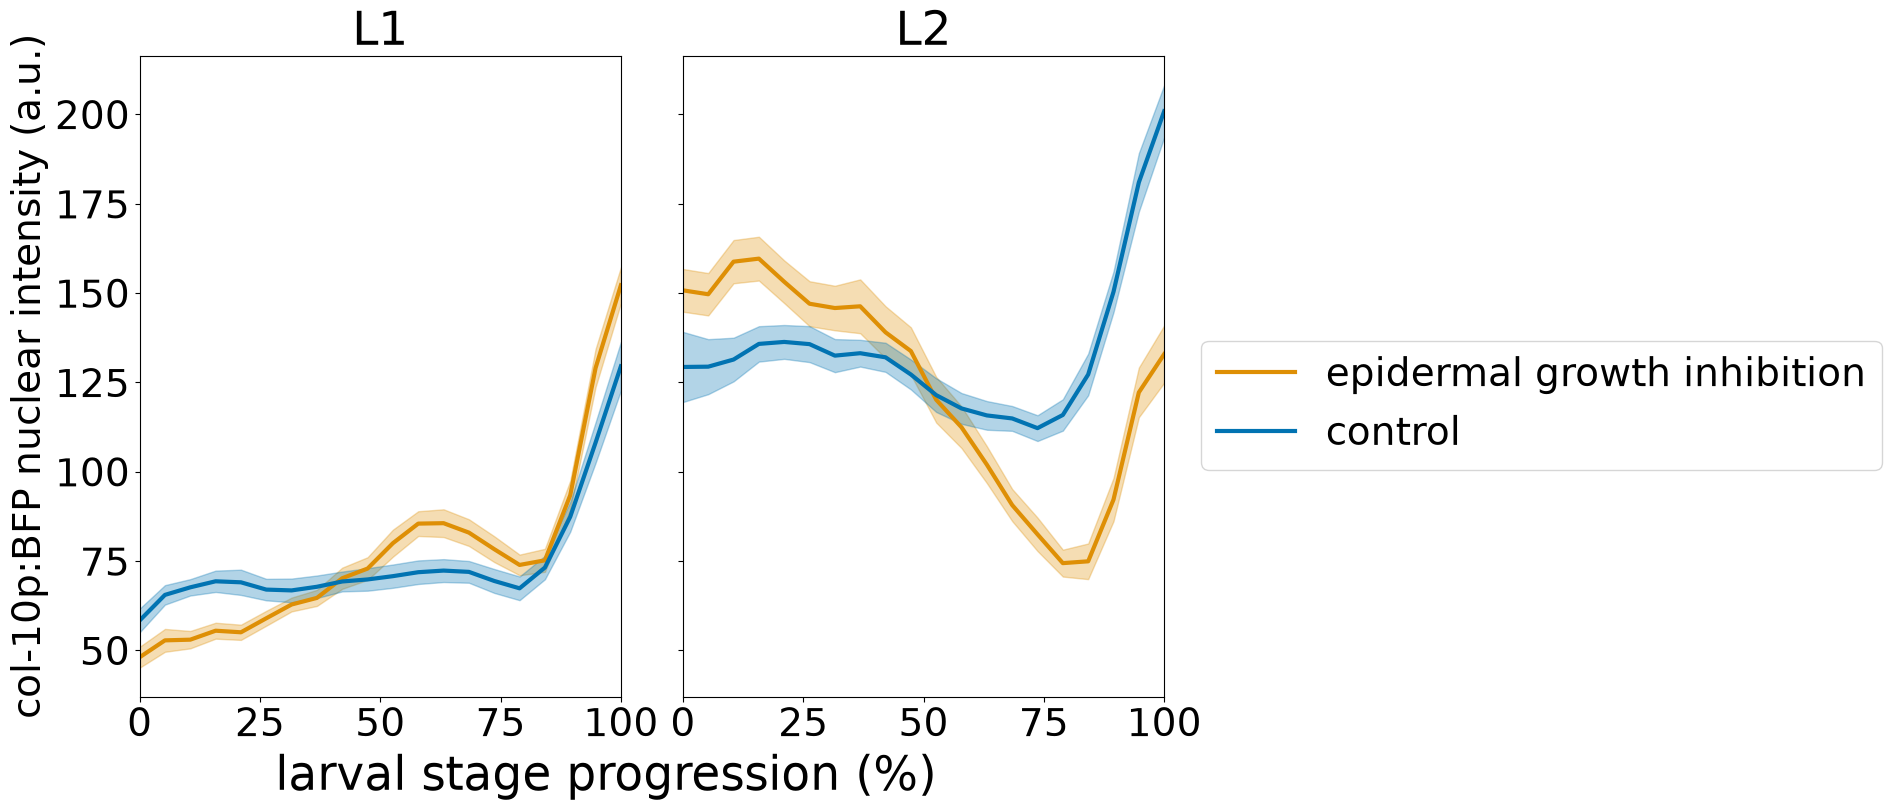

In [18]:
print(experiment_filemap.columns)
fig, axes = rescale_and_plot(
    experiment_filemap,
    "col10_MedianIntensityNucleus_mean",
    n_points=20,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    colors=condition_id_to_color,
    ylabel="col-10p:BFP nuclear intensity (a.u.)",
    output_dir=output_dir,
    filename="col10p_nuclear_intensity_rescaled.pdf",
)


Number of points for condition epidermal growth inhibition: 60
Number of points for condition control: 39


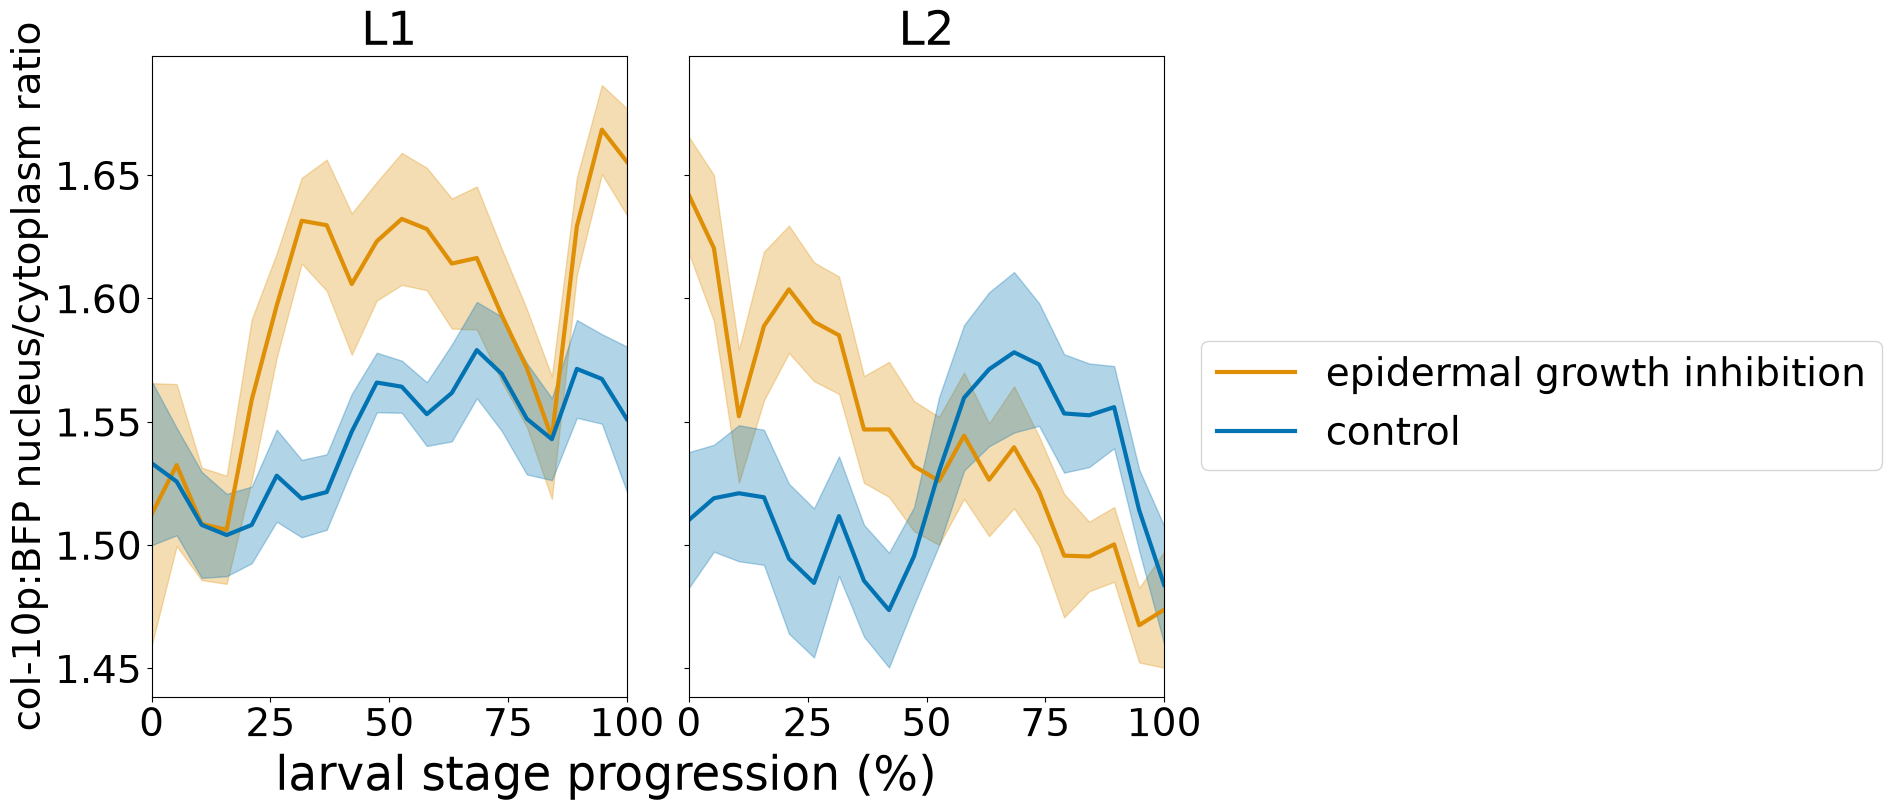

In [19]:
fig, axes = rescale_and_plot(
    experiment_filemap,
    "col10_NucleusCytoplasmRatioMedian_mean",
    n_points=20,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    colors=condition_id_to_color,
    ylabel="col-10p:BFP nucleus/cytoplasm ratio",
    output_dir=output_dir,
    filename="col10p_nucleus_cytoplasm_ratio_rescaled.pdf",
)


In [20]:
def rescale_and_plot_individuals(
    experiment_filemap,
    column,
    *,
    n_points=25,
    n_stages=4,
    descriptions=None,
    colors=None,
    ylabel=None,
    xlabel="larval stage progression (%)",
    stage_names=None,
    ylim=None,
    xlim=(0, 100),
    ci=1.96,
    alpha=0.3,
    figsize_per_stage=(6, 8),
    sharey=True,
    output_dir=None,
    filename=None,
    show=True,
    verbose=True,
    axes=None,
):
    """
    Plot the stage-rescaled mean (+/- CI) of `column`, one subplot per larval stage.

    Parameters
    ----------
    column : str
        Column of `experiment_filemap` to plot.
    n_stages : int | Sequence[int] | Mapping[condition_id, int]
        How many stages to plot per condition. A sequence is matched positionally
        to the partition order; a mapping is keyed by condition_id (recommended).
    descriptions, colors : Mapping[condition_id, str], optional
        Legend labels / line colors. Falls back to the filemap's `description`
        column and matplotlib's default cycle.
    output_dir, filename : str, optional
        If `output_dir` is given, the figure is saved there. `filename` defaults
        to f"{column}_rescaled.pdf".

    Returns
    -------
    fig, axes
    """
    conditions_filemaps = experiment_filemap.partition_by(
        "condition_id", maintain_order=True
    )
    condition_ids = [cfm["condition_id"][0] for cfm in conditions_filemaps]
    limits = _resolve_stage_limits(n_stages, condition_ids)

    max_stages = max(limits.values())
    stage_names = (stage_names or DEFAULT_STAGE_NAMES)[:max_stages]

    if axes is None:
        fig, axes = plt.subplots(
            1,
            max_stages,
            sharey=sharey,
            figsize=(figsize_per_stage[0] * max_stages, figsize_per_stage[1]),
        )
        axes = np.atleast_1d(axes)
    else:
        axes = np.atleast_1d(axes)
        fig = axes[0].get_figure()

    x = np.linspace(0, 100, n_points)

    for condition_filemap, condition_id in zip(conditions_filemaps, condition_ids):
        series_values = separate_column_by_point(condition_filemap, column)
        (
            time,
            experiment_time,
            ecdysis_index,
            ecdysis,
            ecdysis_experiment_time,
        ) = _get_time_ecdysis_and_durations(condition_filemap)

        keep = ~np.isnan(series_values).all(axis=1)
        if not keep.any():
            if verbose:
                print(f"Condition {condition_id}: no valid series, skipping.")
            continue

        series_values = series_values[keep]
        experiment_time = experiment_time[keep]
        ecdysis_index = ecdysis_index[keep]
        qc = np.full_like(series_values, "worm", dtype=object)

        _, rescaled = rescale_series(
            series_values, experiment_time, ecdysis_index, qc, n_points=n_points
        )  # (n_worms, 4, n_points)

        n_stages_condition = limits[condition_id]
        rescaled = rescaled.reshape(rescaled.shape[0], -1)
        rescaled = rescaled[:, : n_points * n_stages_condition]

        label = (
            descriptions[condition_id]
            if descriptions is not None
            else condition_filemap["description"][0]
        )
        color = colors.get(condition_id) if colors is not None else None

        if verbose:
            print(f"Number of points for condition {label}: {rescaled.shape[0]}")


        for stage in range(n_stages_condition):
            sl = slice(stage * n_points, (stage + 1) * n_points)
            ax = axes[stage]
            ax.plot(x, rescaled[:, sl].T, color=color, alpha=0.3)

    for stage, ax in enumerate(axes):
        ax.set_title(stage_names[stage])
        ax.set_ylim(ylim)
        ax.set_xlim(xlim)

    axes[0].set_ylabel(ylabel if ylabel is not None else column)

    handles, labels = [], []
    for ax in axes:
        for hi, li in zip(*ax.get_legend_handles_labels()):
            if li not in labels:
                handles.append(hi)
                labels.append(li)
    if handles:
        fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.98, 0.5))

    fig.supxlabel(xlabel)

    if output_dir is not None:
        path = os.path.join(output_dir, filename or f"{column}_rescaled.pdf")
        fig.savefig(path, bbox_inches="tight")

    if show:
        plt.show()

    return fig, axes

Number of points for condition epidermal growth inhibition: 60
Number of points for condition control: 39


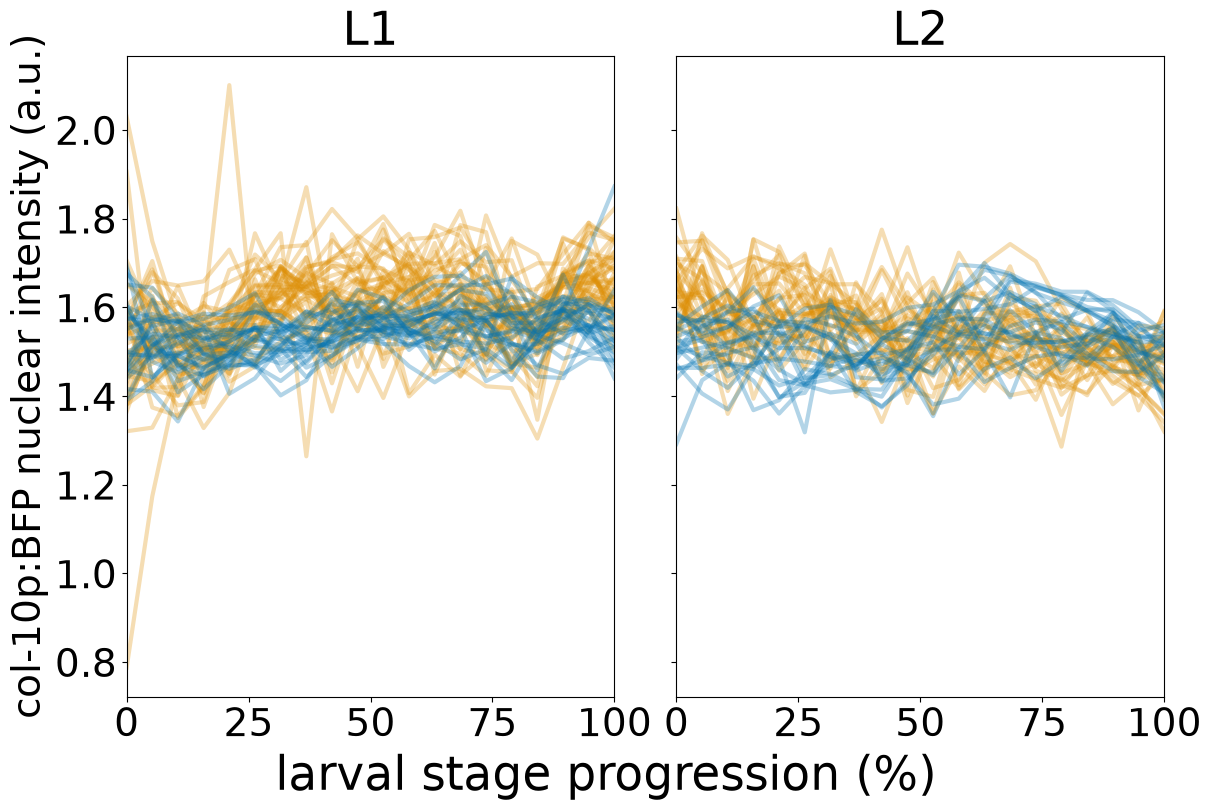

In [21]:
fig, axes = rescale_and_plot_individuals(
    experiment_filemap,
    "col10_NucleusCytoplasmRatioMedian_mean",
    n_points=20,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    colors=condition_id_to_color,
    ylabel="col-10p:BFP nuclear intensity (a.u.)",
    output_dir=output_dir,
    filename="col10p_nuclear_intensity_rescaled.pdf",
)

Number of points for condition epidermal growth inhibition: 60
Number of points for condition control: 39


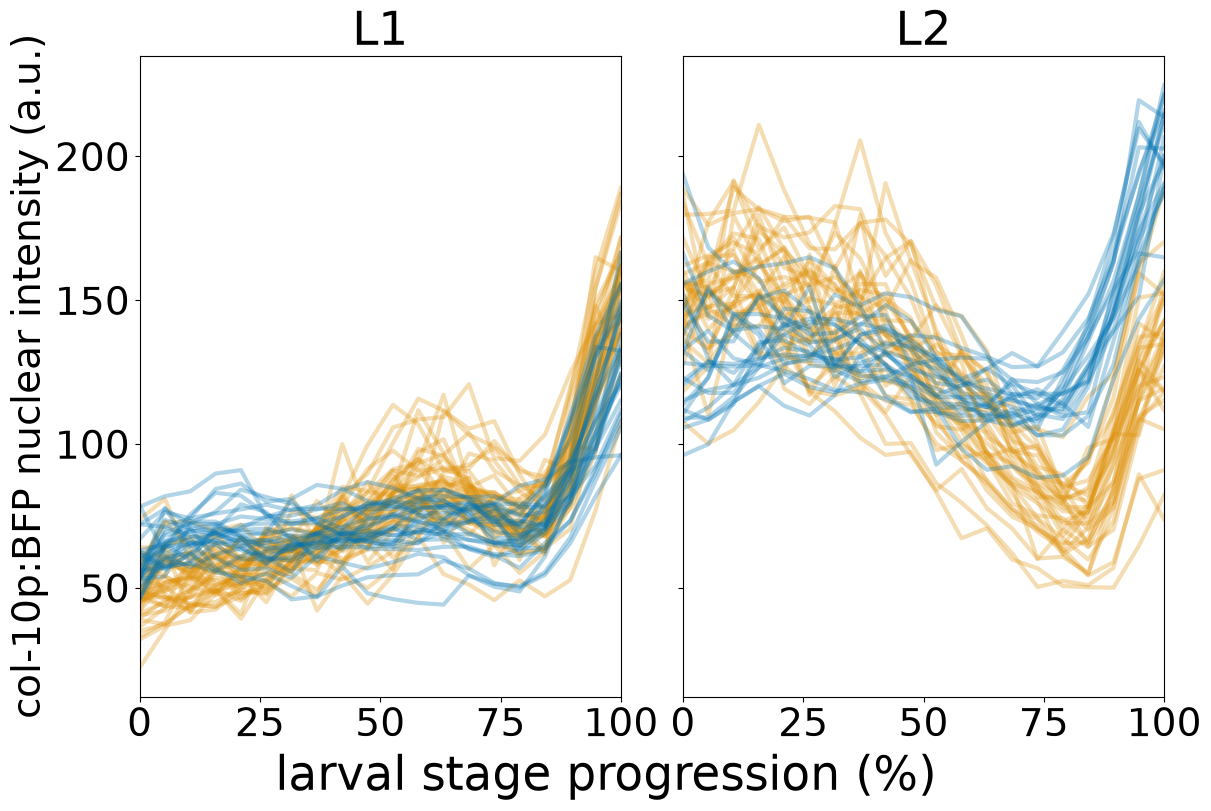

In [22]:
fig, axes = rescale_and_plot_individuals(
    experiment_filemap,
    "col10_MedianIntensityNucleus_mean",
    n_points=20,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    colors=condition_id_to_color,
    ylabel="col-10p:BFP nuclear intensity (a.u.)",
    output_dir=output_dir,
    filename="col10p_nuclear_intensity_rescaled.pdf",
)


Number of points for condition epidermal growth inhibition: 60
Number of points for condition control: 39


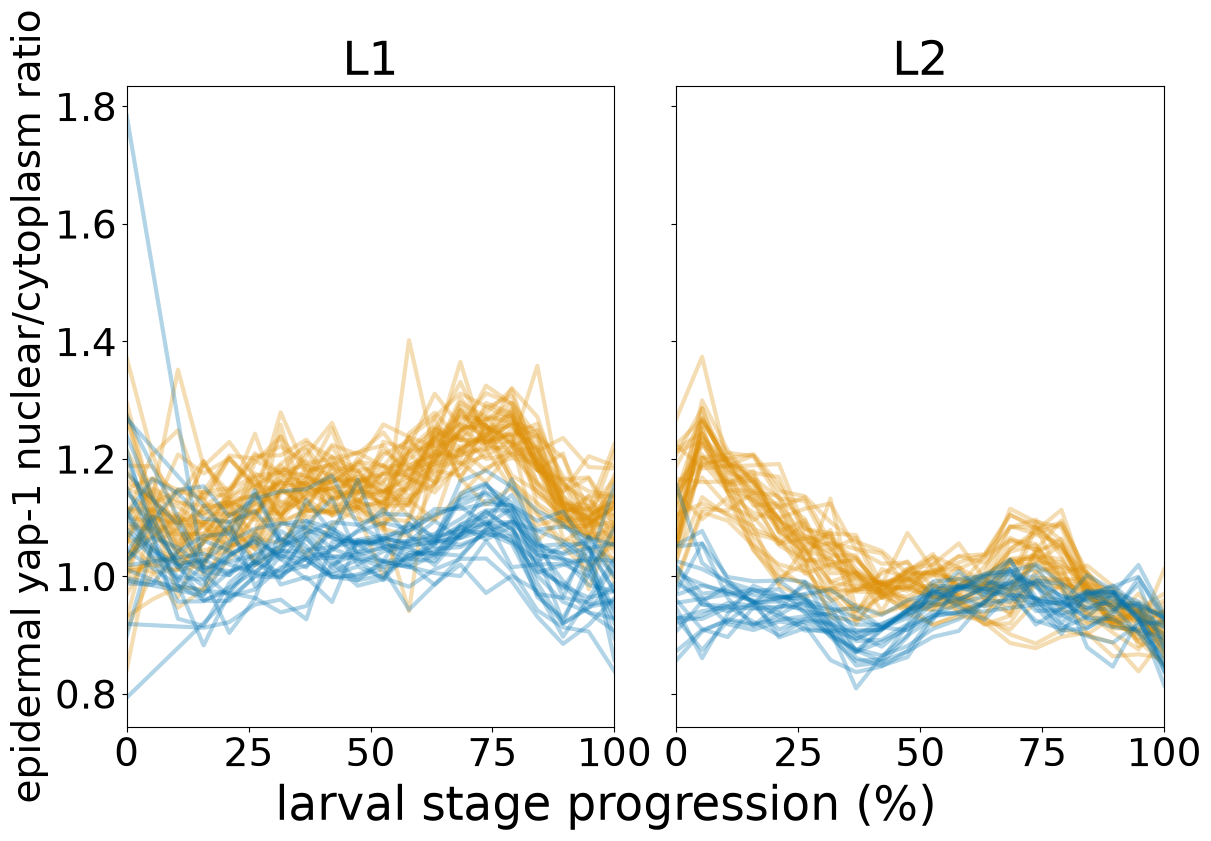

In [23]:
fig, axes = rescale_and_plot_individuals(
    experiment_filemap,
    "NucleusCytoplasmRatioMedian_mean_epidermis",
    n_points=20,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    colors=condition_id_to_color,
    ylabel="epidermal yap-1 nuclear/cytoplasm ratio",
    output_dir=output_dir,
    filename="col10p_nuclear_intensity_rescaled.pdf",
)

Condition 1: epidermal growth inhibition | n_worms=39 | matrix (40, 40) | N median=28 range=[23,41] | 100% of cells above min_n=10


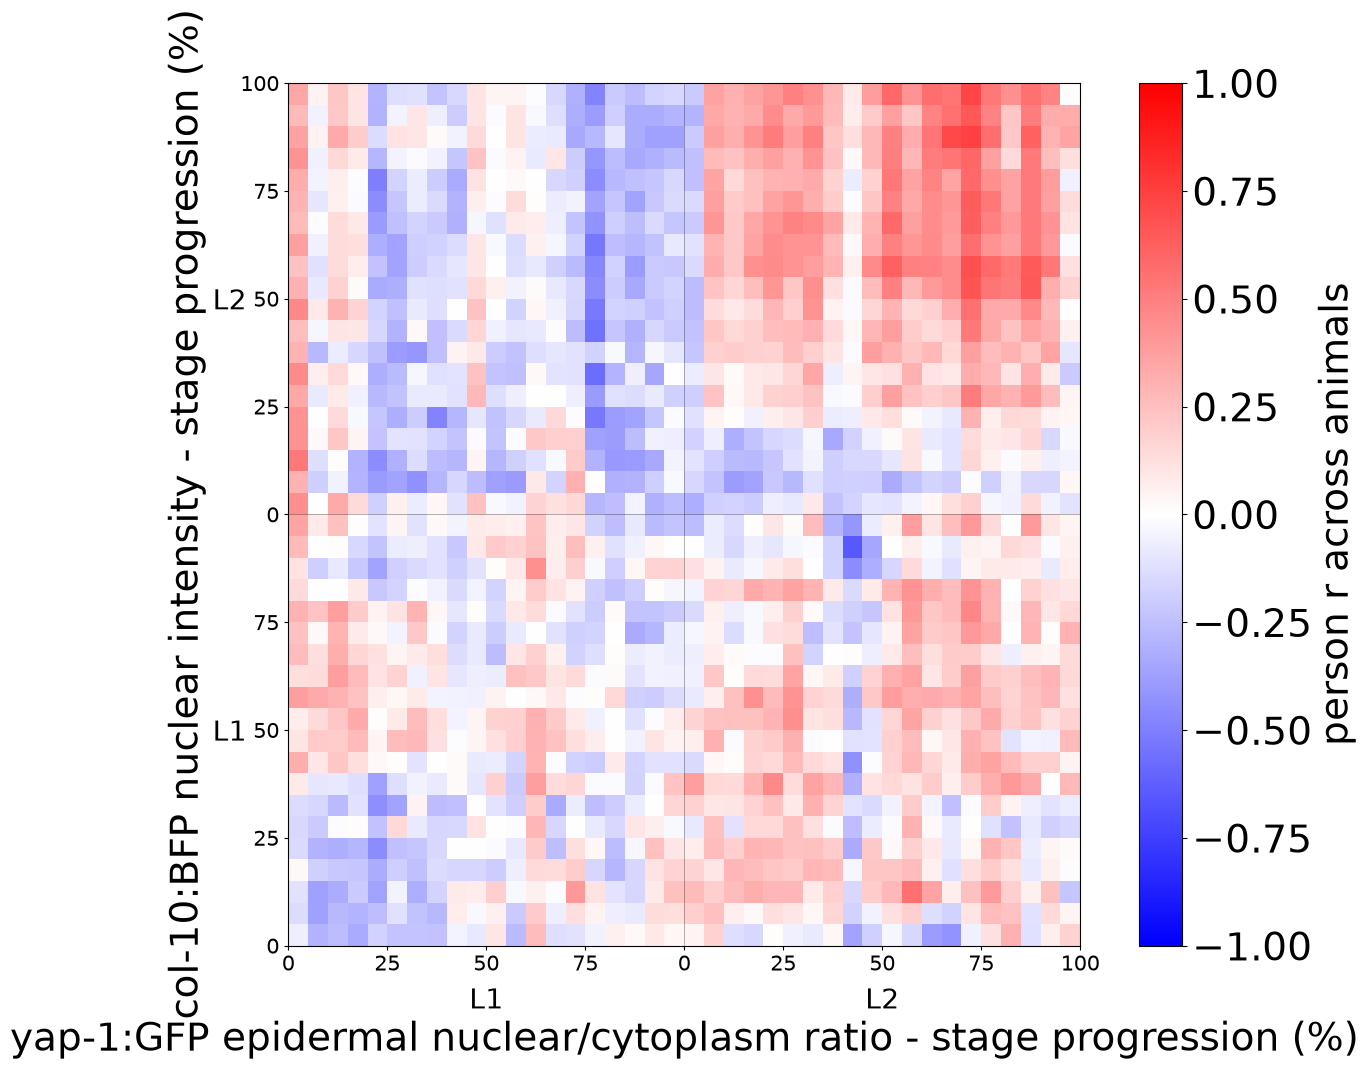

Condition 0: control | n_worms=39 | matrix (40, 40) | N median=17 range=[13,27] | 100% of cells above min_n=10


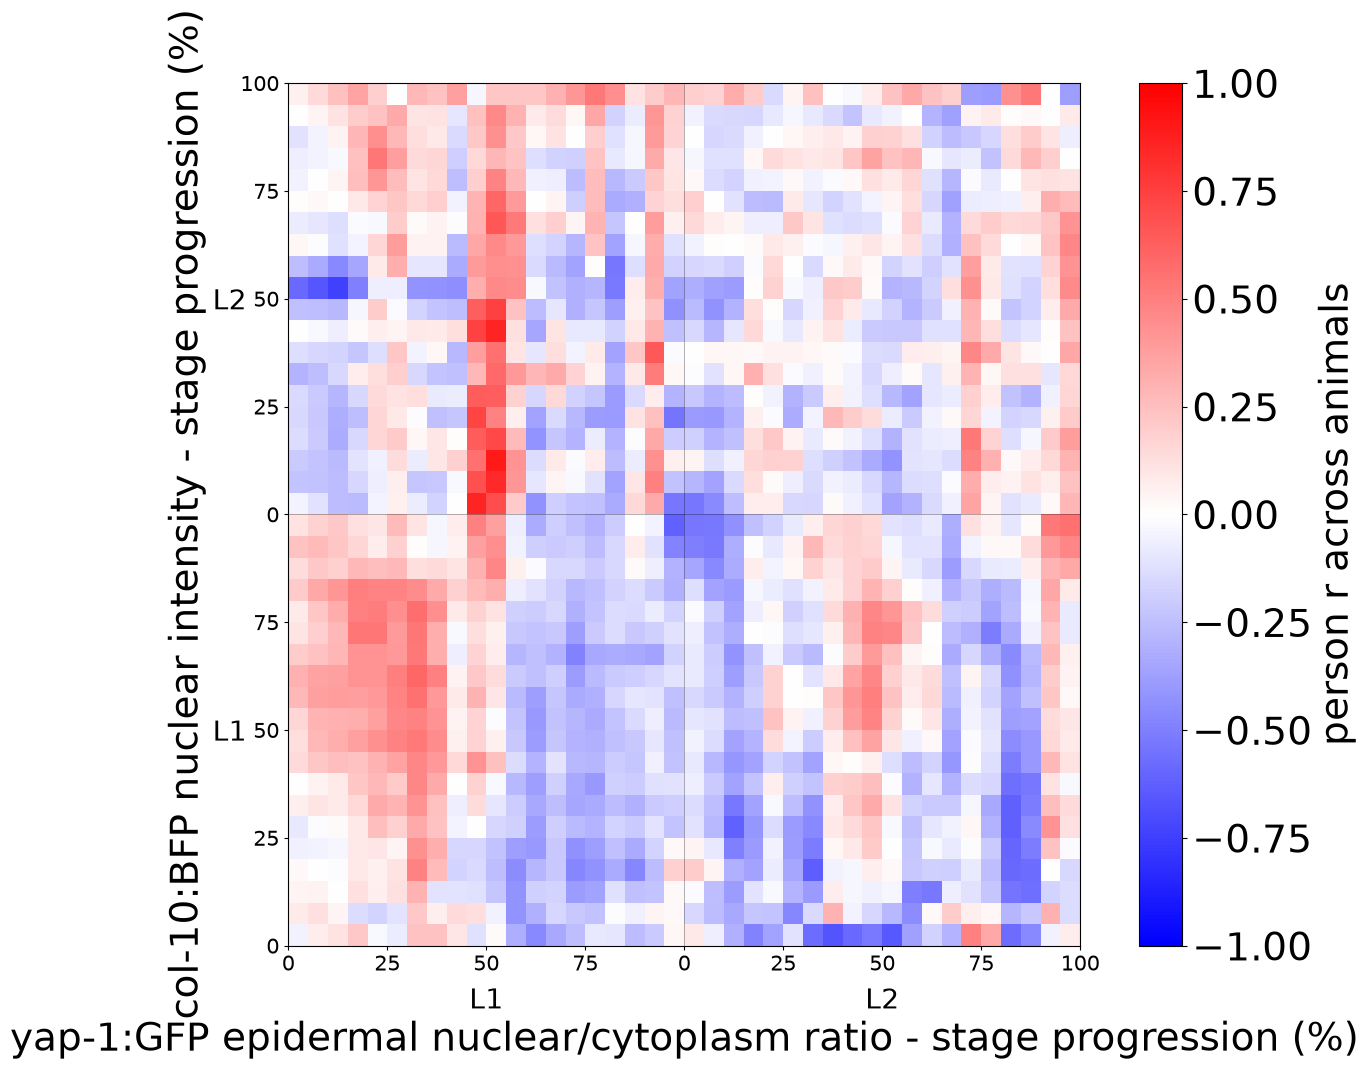

In [25]:
from matplotlib.transforms import blended_transform_factory

def _stage_axis(
    ax,
    which,
    n_stages,
    n_points,
    stage_names,
    label,
    *,
    percent_ticks=(0, 25, 50, 75, 100),
    percent_fontsize=15,
    stage_fontsize=20,
    stage_pad=30,
):
    """Two-level axis: within-stage progression (%) on major ticks, stage names
    centred under each block on minor ticks.

    Stage centres coincide with the 50% major tick; matplotlib drops such minor
    ticks unless remove_overlapping_locs is disabled. Keeping the names as real
    ticks (rather than annotations) lets matplotlib position the axis label and
    compute the tight bbox on its own.
    """
    bounds = np.arange(n_stages + 1) * n_points
    centers = bounds[:-1] + n_points / 2
    names = list(stage_names)[:n_stages]
    is_x = which == "x"
    axis = ax.xaxis if is_x else ax.yaxis

    axis.remove_overlapping_locs = False

    pos, lab = [], []
    for k in range(n_stages):
        for p in percent_ticks:
            if p == 100 and k < n_stages - 1:
                continue  # coincides with 0% of the next stage
            pos.append(k * n_points + p / 100 * n_points)
            lab.append(f"{p:g}")

    axis.set_ticks(pos)
    axis.set_ticklabels(lab, fontsize=percent_fontsize)
    axis.set_tick_params(which="major", length=3, labelsize=percent_fontsize)

    axis.set_ticks(centers, minor=True)
    axis.set_ticklabels(names, minor=True, fontsize=stage_fontsize)
    axis.set_tick_params(which="minor", length=0, pad=stage_pad)

    for b in bounds[1:-1]:
        (ax.axvline if is_x else ax.axhline)(b, color="k", lw=0.6, alpha=0.35)

    (ax.set_xlabel if is_x else ax.set_ylabel)(label)

def nan_corr(A, B=None, min_n=10):
    """Pairwise-complete Pearson correlation between columns of A and columns of B
    (default B=A). Returns (C, N) with C[i, j] = corr(A[:, i], B[:, j]) and N[i, j]
    the number of animals contributing. Cells with N < min_n are set to NaN.
    Vectorised: exact same result as the double loop, ~100x faster."""
    A = np.asarray(A, dtype=float)
    B = A if B is None else np.asarray(B, dtype=float)
    if A.shape[0] != B.shape[0]:
        raise ValueError("A and B must have the same number of rows (animals).")

    fa, fb = np.isfinite(A), np.isfinite(B)
    Az, Bz = np.where(fa, A, 0.0), np.where(fb, B, 0.0)
    Fa, Fb = fa.astype(float), fb.astype(float)

    N = Fa.T @ Fb
    Sa, Sb = Az.T @ Fb, Fa.T @ Bz
    Saa, Sbb = (Az * Az).T @ Fb, Fa.T @ (Bz * Bz)
    Sab = Az.T @ Bz

    with np.errstate(invalid="ignore", divide="ignore"):
        n = np.where(N > 0, N, np.nan)
        cov = Sab - Sa * Sb / n
        va = Saa - Sa**2 / n
        vb = Sbb - Sb**2 / n
        C = cov / np.sqrt(va * vb)

    C[(N < min_n) | ~np.isfinite(C)] = np.nan
    return np.clip(C, -1.0, 1.0), N.astype(int)

def plot_cross_corr_matrix(
    C,
    N,
    ax,
    *,
    n_points,
    n_stages,
    stage_names,
    row_label,
    col_label,
    title=None,
    cmap="RdBu_r",
):
    """C[i, j] = corr(row_series at time i, col_series at time j).
    Rows -> y axis (row_label), columns -> x axis (col_label), origin bottom-left."""
    T1, T2 = C.shape
    im = ax.imshow(
        C,
        vmin=-1,
        vmax=1,
        cmap=cmap,
        origin="lower",
        interpolation="nearest",
        extent=(0, T2, 0, T1),
        aspect="auto",
    )
       
    _stage_axis(ax, "x", n_stages, n_points, stage_names, f"{col_label}")
    _stage_axis(ax, "y", n_stages, n_points, stage_names, f"{row_label}")
    if title:
        ax.set_title(title, fontsize=9)
    return im


def rescale_and_plot_cross_correlation(
    experiment_filemap,
    column_one,
    column_two,
    *,
    column_to_label=None,
    n_points=20,
    n_stages=4,
    descriptions=None,
    stage_names=None,
    min_n=10,
    transform=None,          # e.g. np.log, or a callable (n_worms, T) -> (n_worms, T)
    center_per_animal=False, # subtract each animal's mean trajectory value
    cmap="bwr",
    output_dir=None,
    filename=None,
    verbose=True,
):
    """Cross-animal correlation of column_one vs column_two across rescaled
    developmental time, one panel per condition.

    Returns {condition_id: (C, N)} where C[i, j] = corr over animals of
    column_one at time i against column_two at time j.
    """
    conditions_filemaps = experiment_filemap.partition_by("condition_id", maintain_order=True)
    condition_ids = [cfm["condition_id"][0] for cfm in conditions_filemaps]
    limits = _resolve_stage_limits(n_stages, condition_ids)
    stage_names = list(stage_names or DEFAULT_STAGE_NAMES)

    results = {}
    panels = []

    for condition_filemap, condition_id in zip(conditions_filemaps, condition_ids):
        series_one_values = separate_column_by_point(condition_filemap, column_one)
        series_two_values = separate_column_by_point(condition_filemap, column_two)
        (
            time,
            experiment_time,
            ecdysis_index,
            ecdysis,
            ecdysis_experiment_time,
        ) = _get_time_ecdysis_and_durations(condition_filemap)

        keep = ~np.isnan(series_one_values).all(axis=1) & ~np.isnan(series_two_values).all(axis=1)
        if not keep.any():
            if verbose:
                print(f"Condition {condition_id}: no valid series, skipping.")
            continue

        series_one_values = series_one_values[keep]
        series_two_values = series_two_values[keep]
        experiment_time = experiment_time[keep]
        ecdysis_index = ecdysis_index[keep]
        qc = np.full_like(series_one_values, "worm", dtype=object)

        _, rescaled_one = rescale_series(
            series_one_values, experiment_time, ecdysis_index, qc, n_points=n_points
        )
        _, rescaled_two = rescale_series(
            series_two_values, experiment_time, ecdysis_index, qc, n_points=n_points
        )

        n_stages_condition = limits[condition_id]
        cut = n_points * n_stages_condition
        rescaled_one = rescaled_one.reshape(rescaled_one.shape[0], -1)[:, :cut]
        rescaled_two = rescaled_two.reshape(rescaled_two.shape[0], -1)[:, :cut]

        if transform is not None:
            rescaled_one = transform(rescaled_one)
            rescaled_two = transform(rescaled_two)
        if center_per_animal:
            rescaled_one = rescaled_one - np.nanmean(rescaled_one, axis=1, keepdims=True)
            rescaled_two = rescaled_two - np.nanmean(rescaled_two, axis=1, keepdims=True)

        C, N = nan_corr(rescaled_one, rescaled_two, min_n=min_n)
        results[condition_id] = (C, N)

        panels.append((condition_id, C, N, n_stages_condition))

    if not panels:
        return results

    im = None
    for (condition_id, C, N, n_stages_condition) in panels:
        if verbose:
            desc = descriptions[condition_id] if descriptions is not None else ""
            frac = np.isfinite(C).mean()
            print(
                f"Condition {condition_id}: {desc} | n_worms={rescaled_one.shape[0]} "
                f"| matrix {C.shape} | N median={int(np.median(N))} range=[{N.min()},{N.max()}] "
                f"| {frac:.0%} of cells above min_n={min_n}"
            )
        fig, ax = plt.subplots()
        if column_to_label is not None:
            column_one_label = column_to_label.get(column_one, column_one)
            column_two_label = column_to_label.get(column_two, column_two)
        else:
            column_one_label = column_one
            column_two_label = column_two
        desc = descriptions[condition_id] if descriptions is not None else ""
        im = plot_cross_corr_matrix(
            C,
            N,
            ax,
            n_points=n_points,
            n_stages=n_stages_condition,
            stage_names=stage_names,
            row_label=column_one_label,
            col_label=column_two_label,
            cmap=cmap,
        )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("person r across animals")
        plt.show()
    # return results

column_to_label = {
    "ch1_seg_area": "body area (µm²) - stage progression (%)",
    "col10_MedianIntensityNucleus_mean": "col-10:BFP nuclear intensity - stage progression (%)",
    "NucleusCytoplasmRatioMedian_mean_epidermis": "yap-1:GFP epidermal nuclear/cytoplasm ratio - stage progression (%)",
}
rescale_and_plot_cross_correlation(
    experiment_filemap,
    "col10_MedianIntensityNucleus_mean",
    "NucleusCytoplasmRatioMedian_mean_epidermis",
    column_to_label=column_to_label,
    n_points=20,
    n_stages={0: 2, 1: 2},  # or [2, 3] to keep positional behaviour
    descriptions=new_descriptions,
    output_dir=output_dir,
    filename="col10p_nuclear_intensity_rescaled.pdf",
)